# HVAC Equipment Health — Notebook 01: Exploratory Data Analysis

**Dataset:** ASHRAE Great Energy Predictor III (chilled-water meter, `meter=1`)

**Goals:**
- Understand sensor distributions, correlations, time-series patterns
- Identify data quality issues (missing readings, sensor dropouts, outliers)
- Select buildings with sufficient history (≥90 days) for feature engineering
- Produce figures saved to `figures/`

**Run first:** `conda activate hvac-health`

In [1]:
import sys; sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='darkgrid', palette='muted')
figures = Path('../figures')
figures.mkdir(exist_ok=True)
print('Setup complete')

Setup complete


## 1. Load Raw Data

Expects CSVs at `data/raw/`. Download from Kaggle:
```
kaggle competitions download -c ashrae-energy-prediction -p ../data/raw/
```

In [2]:
from src.features import load_raw
df = load_raw('../data/raw/')
df.head()

Loaded 4,182,440 rows across 498 buildings


,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,air_temperature,cloud_coverage,dew_temperature,wind_speed
0,7,1,2016-02-29 09:00:00,1857.260010,0,Education,121074.0,1989.0,12.8,NaN,8.9,0.0
1,7,1,2016-02-29 10:00:00,2659.250000,0,Education,121074.0,1989.0,12.2,NaN,9.4,0.0
2,7,1,2016-02-29 11:00:00,2912.510010,0,Education,121074.0,1989.0,12.8,NaN,9.4,0.0
3,7,1,2016-02-29 12:00:00,3039.149902,0,Education,121074.0,1989.0,11.1,6.0,8.9,0.0
4,7,1,2016-02-29 13:00:00,3207.989990,0,Education,121074.0,1989.0,13.3,NaN,11.1,0.0


## 2. Missing Data Audit

Sensor dropouts are common in HVAC BMS systems — document the pattern before any feature engineering.

In [3]:
missing = df.isnull().mean().sort_values(ascending=False)
print(missing[missing > 0])

year_built         0.674142
cloud_coverage     0.416574
wind_speed         0.008925
dew_temperature    0.005820
air_temperature    0.005619
dtype: float64


## 3. Meter Reading Distribution

Expect a right-skewed distribution (most buildings have moderate consumption; a few are very large).

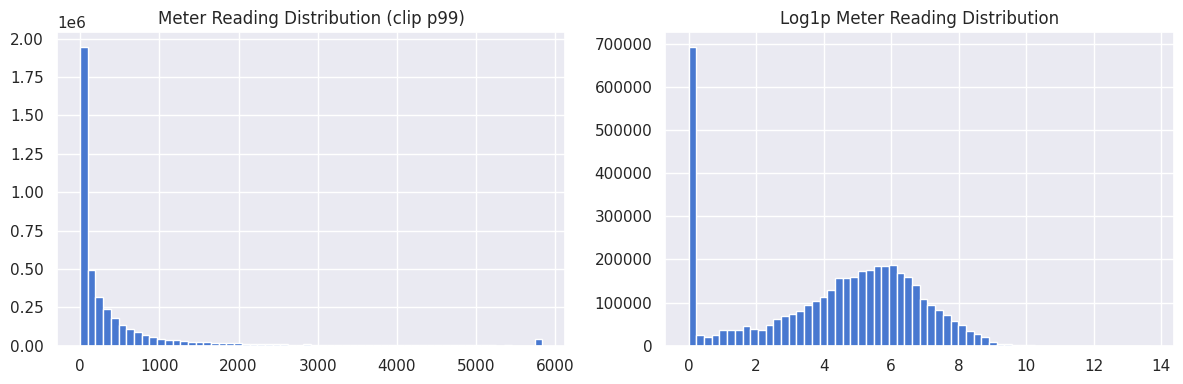

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['meter_reading'].clip(upper=df['meter_reading'].quantile(0.99)).hist(
    bins=60, ax=axes[0])
axes[0].set_title('Meter Reading Distribution (clip p99)')
np.log1p(df['meter_reading']).hist(bins=60, ax=axes[1])
axes[1].set_title('Log1p Meter Reading Distribution')
plt.tight_layout()
fig.savefig(figures / '01_meter_distribution.png', dpi=120)
plt.show()

## 4. Time-Series by Building

Plot a sample of buildings to understand the seasonal/diurnal patterns.

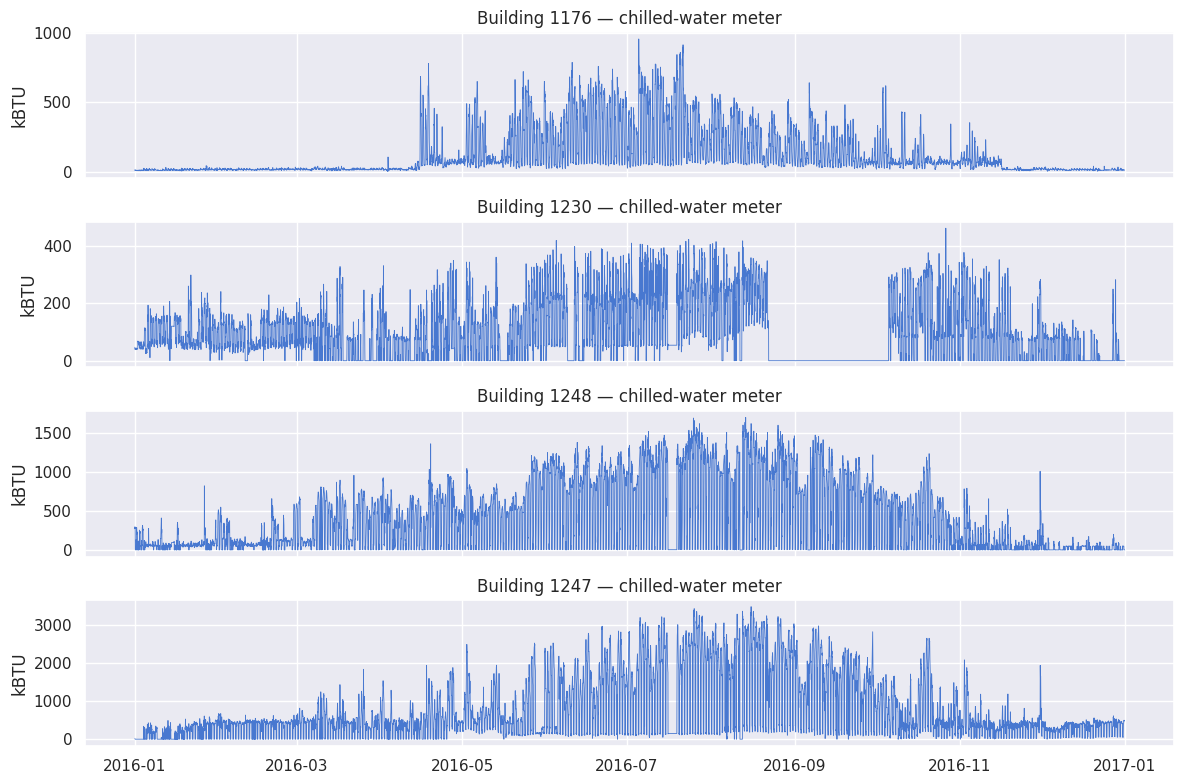

In [5]:
# Pick 4 representative buildings with the most readings and plot meter_reading over time
counts = df.groupby('building_id').size().sort_values(ascending=False)
sample_ids = counts.head(4).index.tolist()
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
for ax, bid in zip(axes, sample_ids):
    sub = df[df['building_id'] == bid].set_index('timestamp')
    ax.plot(sub.index, sub['meter_reading'], linewidth=0.6)
    ax.set_title(f'Building {bid} — chilled-water meter')
    ax.set_ylabel('kBTU')
plt.tight_layout()
fig.savefig(figures / '01_building_timeseries.png', dpi=120)
plt.show()


## 5. Weather Correlations

air_temperature is the primary driver of cooling load — expect strong positive correlation.

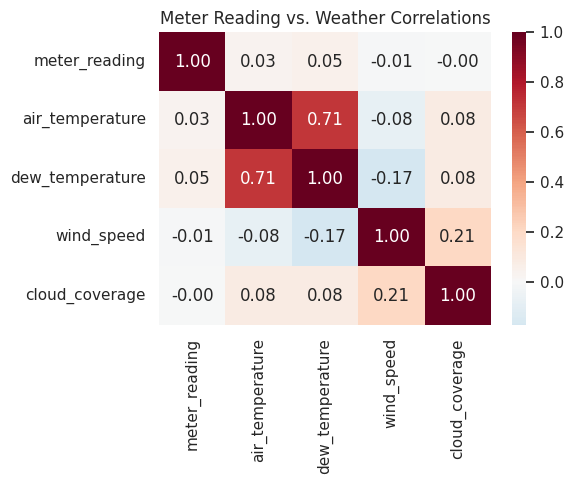

meter_reading      1.000000
dew_temperature    0.049896
air_temperature    0.034307
cloud_coverage    -0.001626
wind_speed        -0.009042
Name: meter_reading, dtype: float64


In [6]:
weather_cols = [c for c in ['meter_reading', 'air_temperature',
                            'dew_temperature', 'wind_speed', 'cloud_coverage']
                if c in df.columns]
corr = df[weather_cols].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Meter Reading vs. Weather Correlations')
plt.tight_layout()
fig.savefig(figures / '01_weather_correlation.png', dpi=120)
plt.show()
print(corr['meter_reading'].sort_values(ascending=False))


## 6. Building Selection

Filter to buildings with ≥90 days of continuous data for feature engineering.

In [7]:
# Coverage per building_id — keep those with at least 90 days (90*24 hours) of non-null readings
coverage = (
    df.groupby('building_id')['meter_reading']
      .apply(lambda s: s.notna().sum())
      .sort_values(ascending=False)
)
qualifying = coverage[coverage >= 90 * 24].index.tolist()
print(f'Total buildings (chilled water): {df["building_id"].nunique()}')
print(f'Buildings with ≥90 days non-null readings: {len(qualifying)}')

# Persist the qualifying list to the processed folder so 02 picks it up
processed = Path('../data/processed')
processed.mkdir(exist_ok=True)
pd.Series(qualifying, name='building_id').to_csv(
    processed / 'qualifying_buildings.csv', index=False)
print(f'Saved {len(qualifying)} building ids to data/processed/qualifying_buildings.csv')


Total buildings (chilled water): 498
Buildings with ≥90 days non-null readings: 497
Saved 497 building ids to data/processed/qualifying_buildings.csv


## Summary

| Finding | Value |
|---------|-------|
| Total buildings (chilled water) | TBD |
| Buildings with ≥90 day coverage | TBD |
| Missing rate (meter_reading) | TBD |
| Correlation (air_temp ↔ meter_reading) | TBD |